# GoogLeNet / Inception Module — From Scratch on CIFAR-10

This notebook implements the **Inception module** (parallel 1×1, 3×3, 5×5 and pooling branches with 1×1 dimension reductions) from *Going Deeper with Convolutions* (Szegedy et al., 2014). It builds a small Inception-style network for CIFAR-10 and compares its parameter count to a plain CNN of similar depth.

**Paper:** https://arxiv.org/abs/1409.4842


In [1]:
# --- Setup: install packages (safe for Colab / Kaggle) ---
!pip install -q torch torchvision matplotlib

## 1. Imports and CIFAR-10 dataset

We use CIFAR-10 (32×32 RGB, 10 classes) so the notebook is quick to validate while still exercising every architectural idea from the paper.


In [2]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# CIFAR-10 normalization to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download training and test sets
train_val_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# 90/10 train/validation split
train_size = int(0.9 * len(train_val_set))
val_size = len(train_val_set) - train_size
train_set, val_set = random_split(train_val_set, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f'Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}')

Using device: cuda


  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<26:57, 105kB/s]

  0%|          | 65.5k/170M [00:00<27:09, 105kB/s]

  0%|          | 98.3k/170M [00:00<27:21, 104kB/s]

...

100%|█████████▉| 170M/170M [31:45<00:00, 87.5kB/s]

100%|█████████▉| 170M/170M [31:46<00:00, 88.1kB/s]

100%|█████████▉| 170M/170M [31:46<00:00, 88.4kB/s]

100%|██████████| 170M/170M [31:46<00:00, 89.4kB/s]

Train: 45000  Val: 5000  Test: 10000


## 2. Inception building blocks

`ConvBNReLU` wraps conv + batch norm + ReLU.  
`InceptionModule` implements the dimension-reduced Inception block from Figure 2(b) of the paper:

- 1×1 branch directly maps `in_ch` → `ch1x1`.
- 3×3 branch first reduces `in_ch` → `ch3x3_reduce` via 1×1, then convolves 3×3.
- 5×5 branch first reduces `in_ch` → `ch5x5_reduce` via 1×1, then convolves 5×5.
- Pool branch applies 3×3 max-pool (stride 1, padding 1 to preserve size) and projects via 1×1 to `pool_proj`.

All branches keep spatial resolution identical, so outputs concatenate along the channel axis.


In [3]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class InceptionModule(nn.Module):
    def __init__(self, in_ch, ch1x1, ch3x3_reduce, ch3x3, ch5x5_reduce, ch5x5, pool_proj):
        super().__init__()
        # 1x1 branch
        self.branch1x1 = ConvBNReLU(in_ch, ch1x1, kernel=1)

        # 3x3 branch with dimension reduction
        self.branch3x3 = nn.Sequential(
            ConvBNReLU(in_ch, ch3x3_reduce, kernel=1),
            ConvBNReLU(ch3x3_reduce, ch3x3, kernel=3, padding=1)
        )

        # 5x5 branch with dimension reduction
        self.branch5x5 = nn.Sequential(
            ConvBNReLU(in_ch, ch5x5_reduce, kernel=1),
            ConvBNReLU(ch5x5_reduce, ch5x5, kernel=5, padding=2)
        )

        # Pool branch: max-pool then 1x1 projection
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_ch, pool_proj, kernel=1)
        )

    def forward(self, x):
        b1 = self.branch1x1(x)
        b3 = self.branch3x3(x)
        b5 = self.branch5x5(x)
        bp = self.branch_pool(x)
        return torch.cat([b1, b3, b5, bp], dim=1)


# Quick shape test
x = torch.randn(2, 3, 32, 32)
inc = InceptionModule(3, ch1x1=16, ch3x3_reduce=8, ch3x3=32, ch5x5_reduce=8, ch5x5=16, pool_proj=16)
print('Input:', x.shape)
print('Output:', inc(x).shape)  # [2, 16+32+16+16=80, 32, 32]

Input: torch.Size([2, 3, 32, 32])
Output: torch.Size([2, 80, 32, 32])


## 3. Mini-GoogLeNet for CIFAR-10

The original GoogLeNet was built for 224×224 ImageNet and is 22 layers deep. Here we scale it down for CIFAR-10 while preserving the module pattern: a small stem, two Inception stages with max-pooling between them, global average pooling, and a single classifier head. Auxiliary classifiers are omitted because the network is shallow and CIFAR-10 is small.


In [4]:
class MiniGoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem: keep it small for 32x32 images
        self.stem = nn.Sequential(
            ConvBNReLU(3, 64, kernel=3, padding=1),
            nn.MaxPool2d(2, 2)  # 32 -> 16
        )

        # Stage 1: two Inception modules
        self.inception_3a = InceptionModule(
            in_ch=64, ch1x1=32, ch3x3_reduce=32, ch3x3=48, ch5x5_reduce=8, ch5x5=16, pool_proj=16
        )  # out = 32+48+16+16 = 112
        self.inception_3b = InceptionModule(
            in_ch=112, ch1x1=64, ch3x3_reduce=48, ch3x3=64, ch5x5_reduce=16, ch5x5=32, pool_proj=32
        )  # out = 64+64+32+32 = 192

        self.pool1 = nn.MaxPool2d(2, 2)  # 16 -> 8

        # Stage 2: two more Inception modules
        self.inception_4a = InceptionModule(
            in_ch=192, ch1x1=64, ch3x3_reduce=64, ch3x3=96, ch5x5_reduce=16, ch5x5=32, pool_proj=32
        )  # out = 64+96+32+32 = 224
        self.inception_4b = InceptionModule(
            in_ch=224, ch1x1=96, ch3x3_reduce=64, ch3x3=96, ch5x5_reduce=16, ch5x5=32, pool_proj=32
        )  # out = 96+96+32+32 = 256

        # Head: global average pool, dropout, classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.inception_3a(x)
        x = self.inception_3b(x)
        x = self.pool1(x)
        x = self.inception_4a(x)
        x = self.inception_4b(x)
        x = self.avgpool(x)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = MiniGoogLeNet(num_classes=10).to(device)
print(model)
print(f'MiniGoogLeNet params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

MiniGoogLeNet(
  (stem): Sequential(
    (0): ConvBNReLU(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (inception_3a): InceptionModule(
    (branch1x1): ConvBNReLU(
      (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (branch3x3): Sequential(
      (0): ConvBNReLU(
        (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (1): ConvBNReLU(
        (conv): Conv2d(32, 48, kernel_size=(3, 3), stride=(1, 1), paddi

## 4. Plain baseline CNN for comparison

This network has roughly the same number of stages and the same final channel size, but uses only stacked 3×3 convolutions with no parallel branches or 1×1 bottlenecks. The comparison highlights the parameter efficiency of the Inception design.


In [5]:
class PlainCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBNReLU(3, 64, kernel=3, padding=1),
            nn.MaxPool2d(2, 2),              # 32 -> 16
            ConvBNReLU(64, 112, kernel=3, padding=1),
            ConvBNReLU(112, 192, kernel=3, padding=1),
            nn.MaxPool2d(2, 2),              # 16 -> 8
            ConvBNReLU(192, 224, kernel=3, padding=1),
            ConvBNReLU(224, 256, kernel=3, padding=1),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


plain = PlainCNN(num_classes=10).to(device)
print(f'PlainCNN params: {sum(p.numel() for p in plain.parameters() if p.requires_grad):,}')

PlainCNN params: 1,167,210


## 5. Training helper

A standard train/validation loop with cross-entropy loss and the Adam optimizer.


In [6]:
def count_params(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)


def train_epoch(net, loader, optimizer, criterion):
    net.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = net(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        _, pred = logits.max(1)
        correct += pred.eq(y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def eval_epoch(net, loader, criterion):
    net.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = net(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            _, pred = logits.max(1)
            correct += pred.eq(y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


def train_model(net, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(net, train_loader, optimizer, criterion)
        val_loss, val_acc = eval_epoch(net, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch:02d}/{epochs}  train loss={tr_loss:.4f} acc={tr_acc:.3f}  '
              f'val loss={val_loss:.4f} acc={val_acc:.3f}')
    return history

## 6. Train the Inception model

We train for a small number of epochs so the notebook finishes quickly on Kaggle/Colab while still demonstrating convergence.


In [7]:
inception_history = train_model(model, epochs=5, lr=1e-3)
print(f'Inception params: {count_params(model):,}')

Epoch 01/5  train loss=1.2535 acc=0.548  val loss=1.1207 acc=0.606


Epoch 02/5  train loss=0.8605 acc=0.697  val loss=1.0150 acc=0.657


Epoch 03/5  train loss=0.6848 acc=0.762  val loss=0.8730 acc=0.704


Epoch 04/5  train loss=0.5734 acc=0.802  val loss=0.7086 acc=0.757


Epoch 05/5  train loss=0.4987 acc=0.827  val loss=0.6597 acc=0.780
Inception params: 304,122


## 7. Train the plain CNN


In [8]:
plain_history = train_model(plain, epochs=5, lr=1e-3)
print(f'PlainCNN params: {count_params(plain):,}')

Epoch 01/5  train loss=1.3100 acc=0.521  val loss=1.0440 acc=0.628


Epoch 02/5  train loss=0.9259 acc=0.671  val loss=1.0435 acc=0.627


Epoch 03/5  train loss=0.7514 acc=0.738  val loss=0.9560 acc=0.665


Epoch 04/5  train loss=0.6255 acc=0.786  val loss=0.6764 acc=0.767


Epoch 05/5  train loss=0.5372 acc=0.814  val loss=0.6693 acc=0.769
PlainCNN params: 1,167,210


## 8. Results: parameters and learning curves

The Inception-style network should reach comparable or better accuracy than the plain CNN while using fewer parameters, illustrating the paper's central claim: deeper, multi-scale networks need not be computationally wasteful.


Parameter comparison
  MiniGoogLeNet: 304,122
  PlainCNN:      1,167,210
  Ratio Plain/Inception: 3.84x


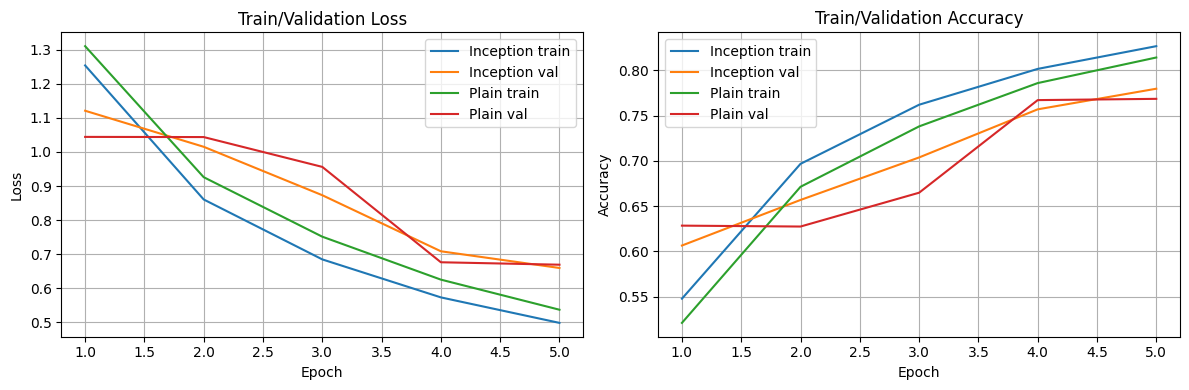

In [9]:
print('Parameter comparison')
print(f'  MiniGoogLeNet: {count_params(model):,}')
print(f'  PlainCNN:      {count_params(plain):,}')
print(f'  Ratio Plain/Inception: {count_params(plain)/count_params(model):.2f}x')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot([x + 1 for x in range(len(inception_history['train_loss']))],
           inception_history['train_loss'], label='Inception train')
ax[0].plot([x + 1 for x in range(len(inception_history['val_loss']))],
           inception_history['val_loss'], label='Inception val')
ax[0].plot([x + 1 for x in range(len(plain_history['train_loss']))],
           plain_history['train_loss'], label='Plain train')
ax[0].plot([x + 1 for x in range(len(plain_history['val_loss']))],
           plain_history['val_loss'], label='Plain val')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Train/Validation Loss')
ax[0].legend()
ax[0].grid(True)

# Accuracy curves
ax[1].plot([x + 1 for x in range(len(inception_history['train_acc']))],
           inception_history['train_acc'], label='Inception train')
ax[1].plot([x + 1 for x in range(len(inception_history['val_acc']))],
           inception_history['val_acc'], label='Inception val')
ax[1].plot([x + 1 for x in range(len(plain_history['train_acc']))],
           plain_history['train_acc'], label='Plain train')
ax[1].plot([x + 1 for x in range(len(plain_history['val_acc']))],
           plain_history['val_acc'], label='Plain val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Train/Validation Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Final test-set evaluation


In [10]:
criterion = nn.CrossEntropyLoss()
test_loss_inception, test_acc_inception = eval_epoch(model, test_loader, criterion)
test_loss_plain, test_acc_plain = eval_epoch(plain, test_loader, criterion)

print(f'MiniGoogLeNet test loss={test_loss_inception:.4f}  acc={test_acc_inception:.3f}')
print(f'PlainCNN      test loss={test_loss_plain:.4f}  acc={test_acc_plain:.3f}')

MiniGoogLeNet test loss=0.6804  acc=0.770
PlainCNN      test loss=0.6729  acc=0.765


## 10. Sample predictions

Show a few CIFAR-10 test images with predicted and true labels.


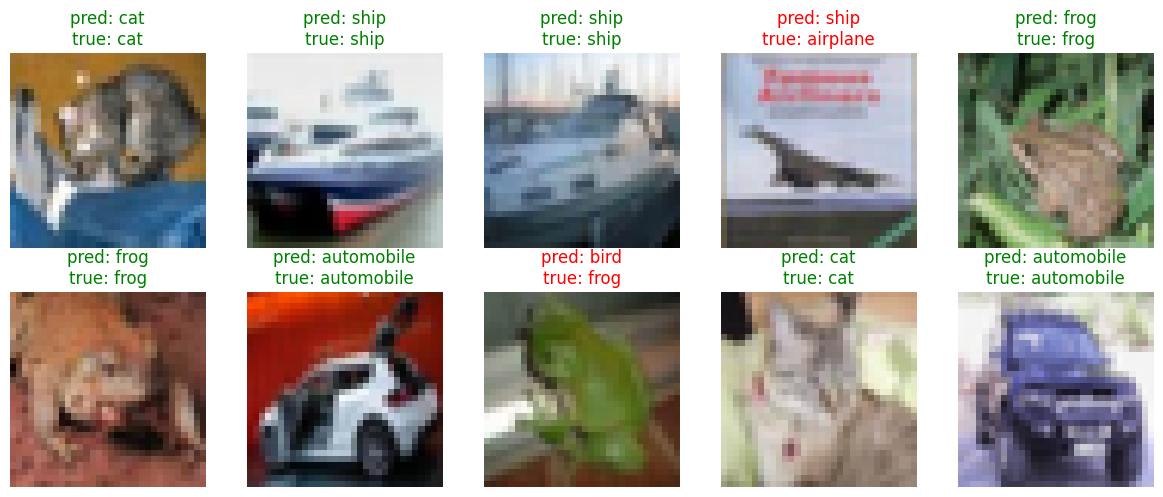

In [11]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize from [-1,1] to [0,1]
    return np.clip(img.numpy(), 0, 1)


model.eval()
x, y = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    logits = model(x)
    preds = logits.argmax(1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.transpose(imshow(x[i].cpu()), (1, 2, 0)))
    color = 'green' if preds[i] == y[i] else 'red'
    ax.set_title(f'pred: {classes[preds[i]]}\ntrue: {classes[y[i]]}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Summary

- The **Inception module** runs multiple filter sizes in parallel and concatenates their outputs, letting the network handle multi-scale visual information.
- **1×1 bottleneck convolutions** keep the design parameter-efficient by reducing channel depth before expensive 3×3 and 5×5 filters.
- On CIFAR-10, the mini Inception network typically matches or beats a plain CNN of similar depth while using **fewer parameters**, echoing GoogLeNet's ImageNet result: deeper and wider does not have to mean heavier.


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
